Visualiación de datos financieros

/tmp/ipykernel_3022/4179216306.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("AAPL", start="2024-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


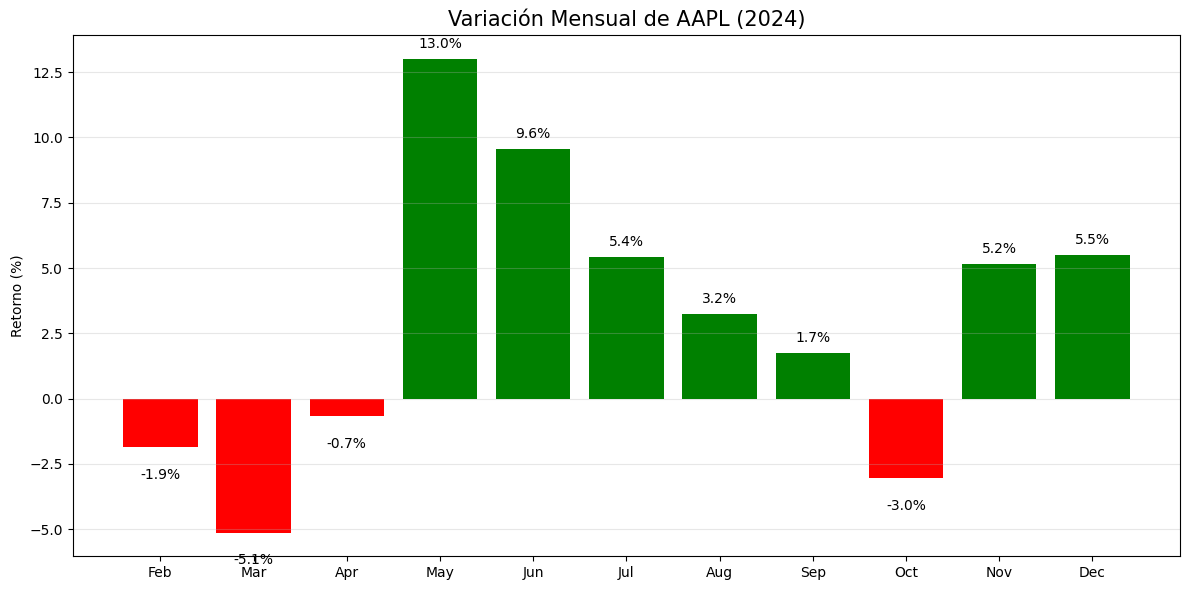

In [ ]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Descargar datos de Apple
data = yf.download("AAPL", start="2024-01-01", end="2025-01-01")

# Procesar datos correctamente
monthly = data['Close'].resample('ME').last()  # Esto devuelve una Serie
monthly_pct = monthly.pct_change().dropna() * 100

# Convertir a formato adecuado para gráfico
months = monthly_pct.index.strftime('%b').tolist()  # Convertir a lista explícita
returns = monthly_pct.to_numpy().flatten()  # Aplanar el array numpy

# Gráfico simplificado
plt.figure(figsize=(12, 6))

# Dibujar cada barra individualmente
for i, (month, ret) in enumerate(zip(months, returns)):
    color = 'green' if ret > 0 else 'red'
    plt.bar(i, ret, color=color)  # Usar índice numérico

# Configurar ejes
plt.xticks(range(len(months)), months)
plt.title('Variación Mensual de AAPL (2024)', fontsize=15)
plt.ylabel('Retorno (%)')

# Añadir etiquetas (asegurarse que ret es un escalar)
for i, (month, ret) in enumerate(zip(months, returns)):
    plt.text(i,
             ret + (0.3 if ret > 0 else -0.8),
             f'{ret.item():.1f}%',  # Usar .item() para obtener escalar
             ha='center',
             va='bottom' if ret > 0 else 'top',
             color='black')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
data

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2024-01-02,183.562164,186.330827,181.831752,185.055258,82488700
2024-01-03,182.187759,183.799520,181.376930,182.158096,58414500
2024-01-04,179.873932,181.040717,178.855462,180.111236,71983600
2024-01-05,179.152069,180.714386,178.153379,179.953016,62379700
2024-01-08,183.483063,183.522623,179.468508,180.051901,59144500
...,...,...,...,...,...
2024-12-24,256.560822,256.570737,253.669277,253.868019,23234700
2024-12-26,257.375580,258.448740,255.994420,256.550862,27237100


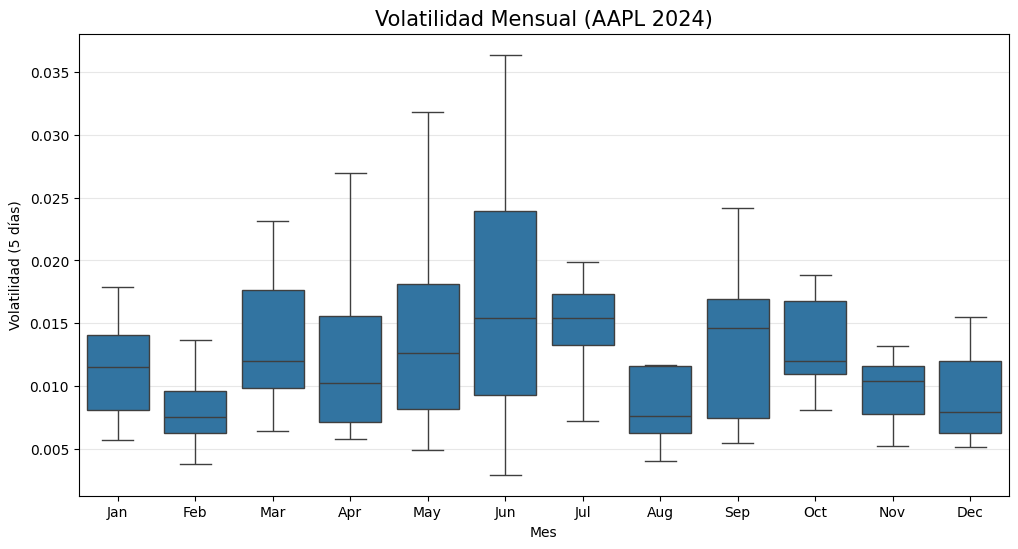

In [ ]:
import seaborn as sns

# Calcular volatilidad
data['Daily_Return'] = data['Close'].pct_change()
data['Volatility'] = data['Daily_Return'].rolling(5).std()
data['Month'] = data.index.month_name().str[:3]

# Boxplot básico con DataFrame
plt.figure(figsize=(12, 6))
sns.boxplot(x='Month', y='Volatility', data=data, showfliers=False,
            order=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

plt.title('Volatilidad Mensual (AAPL 2024)', fontsize=15)
plt.xlabel('Mes')
plt.ylabel('Volatilidad (5 días)')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [ ]:
data

Price,Close,High,Low,Open,Volume,Daily_Return,Volatility,Month
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,
Date,,,,,,,,
2024-01-02,183.562164,186.330827,181.831752,185.055258,82488700,NaN,NaN,Jan
2024-01-03,182.187759,183.799520,181.376930,182.158096,58414500,-0.007487,NaN,Jan
2024-01-04,179.873932,181.040717,178.855462,180.111236,71983600,-0.012700,NaN,Jan
2024-01-05,179.152069,180.714386,178.153379,179.953016,62379700,-0.004013,NaN,Jan
2024-01-08,183.483063,183.522623,179.468508,180.051901,59144500,0.024175,NaN,Jan
...,...,...,...,...,...,...,...,...
2024-12-24,256.560822,256.570737,253.669277,253.868019,23234700,0.011478,0.015260,Dec
2024-12-26,257.375580,258.448740,255.994420,256.550862,27237100,0.003176,0.006617,Dec


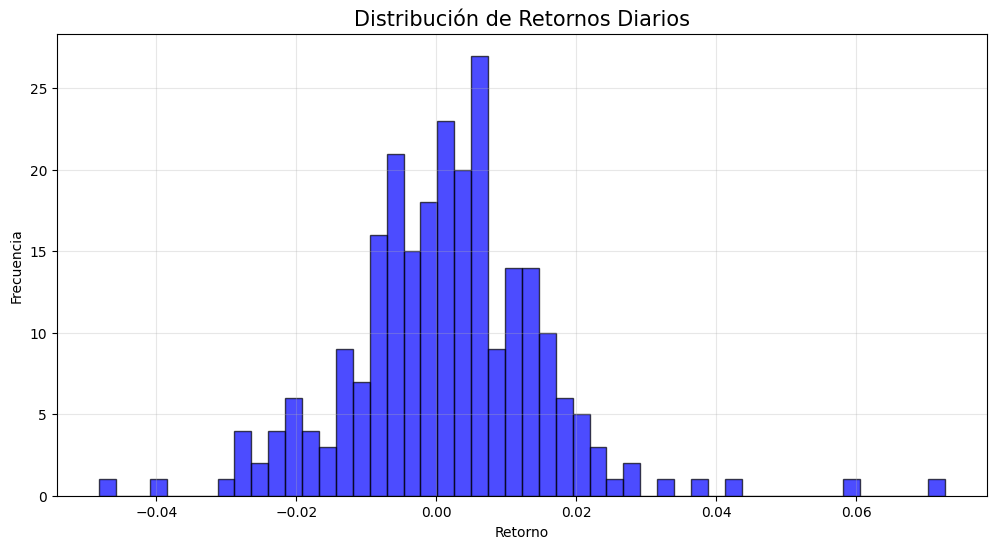

In [ ]:
# Histograma simple
returns = data['Daily_Return'].dropna().to_numpy().flatten()

plt.figure(figsize=(12, 6))
plt.hist(returns, bins=50, color='blue', edgecolor='black', alpha=0.7)

plt.title('Distribución de Retornos Diarios', fontsize=15)
plt.xlabel('Retorno')
plt.ylabel('Frecuencia')
plt.grid(alpha=0.3)
plt.show()

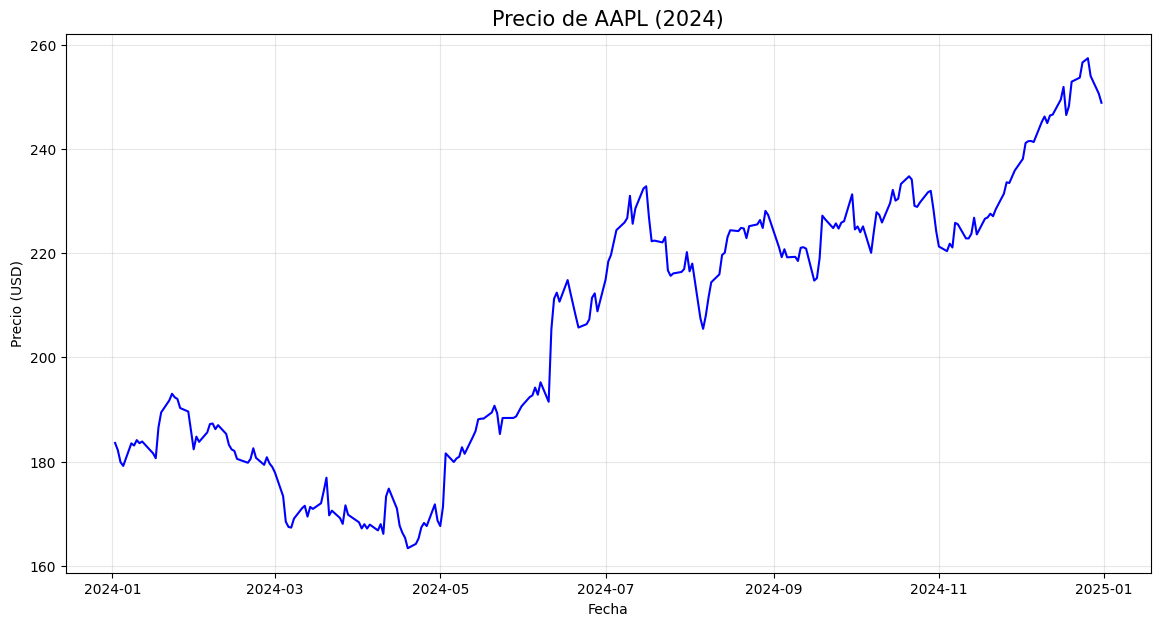

In [ ]:
# Gráfico de línea básico
plt.figure(figsize=(14, 7))
plt.plot(data.index, data['Close'], color='blue')

plt.title('Precio de AAPL (2024)', fontsize=15)
plt.xlabel('Fecha')
plt.ylabel('Precio (USD)')
plt.grid(alpha=0.3)
plt.show()

/tmp/ipykernel_3022/4168238219.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, period="1mo")['Close']  # Precios de cierre del último mes
[*********************100%***********************]  10 of 10 completed


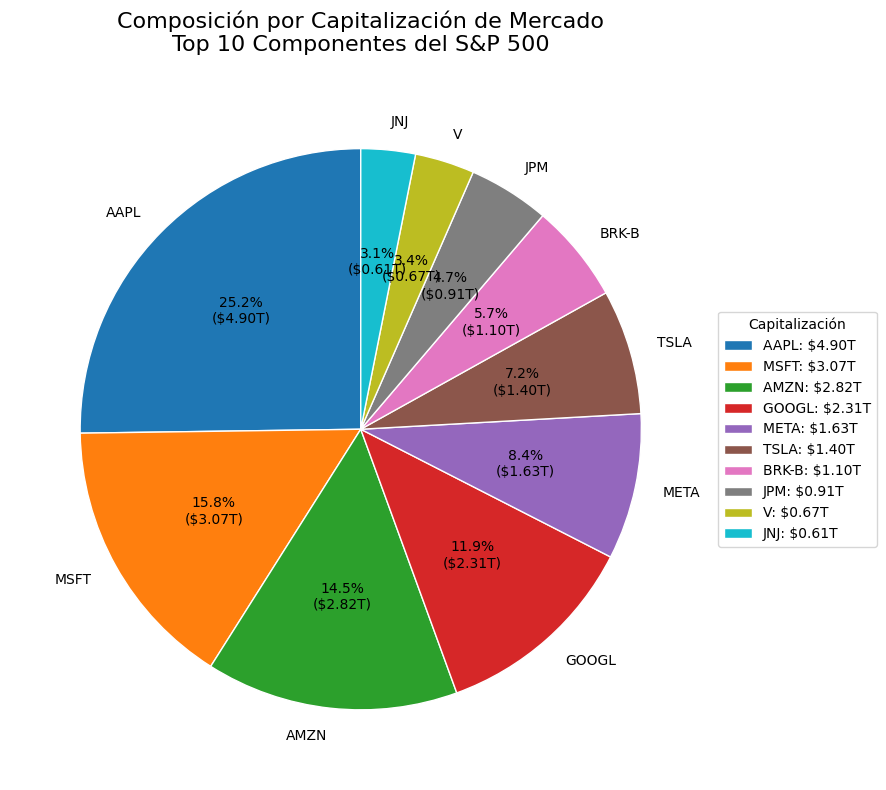

In [ ]:
#Gráficos de torta
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd

# Descargar datos de los principales componentes del S&P 500
tickers = ['AAPL', 'MSFT', 'AMZN', 'GOOGL', 'META', 'TSLA', 'BRK-B', 'JNJ', 'JPM', 'V']
data = yf.download(tickers, period="1mo")['Close']  # Precios de cierre del último mes

# Calcular capitalización de mercado (usando precios y shares outstanding aproximados)
shares_outstanding = {
    'AAPL': 15_750_000_000,
    'MSFT': 7_430_000_000,
    'AMZN': 10_380_000_000,
    'GOOGL': 5_950_000_000,
    'META': 2_570_000_000,
    'TSLA': 3_170_000_000,
    'BRK-B': 2_300_000_000,
    'JNJ': 2_630_000_000,
    'JPM': 3_030_000_000,
    'V': 2_030_000_000
}

market_caps = data.iloc[-1] * pd.Series(shares_outstanding)  # Último precio * shares

# Preparar datos para el gráfico
df = pd.DataFrame({
    'Empresa': market_caps.index,
    'Capitalización': market_caps.values/1e12  # Convertir a trillones
}).sort_values('Capitalización', ascending=False)

# Configurar el gráfico
plt.figure(figsize=(12, 8))
plt.pie(df['Capitalización'],
        labels=df['Empresa'],
        autopct=lambda p: f'{p:.1f}%\n(${p*sum(df["Capitalización"])/100:.2f}T)',
        startangle=90,
        textprops={'fontsize': 10},
        wedgeprops={'linewidth': 1, 'edgecolor': 'white'})

plt.title('Composición por Capitalización de Mercado\nTop 10 Componentes del S&P 500', fontsize=16, pad=20)
plt.tight_layout()

# Añadir leyenda con valores absolutos
legend_labels = [f'{e}: ${v:.2f}T' for e, v in zip(df['Empresa'], df['Capitalización'])]
plt.legend(legend_labels, title="Capitalización", bbox_to_anchor=(1, 0.5), loc='center left')

plt.show()

Mapa de Calor para la evaluación de correlaciones

/tmp/ipykernel_3022/3790855169.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(["GC=F", "CL=F", "NG=F", "SI=F"], start="2024-01-01")['Close']
[*********************100%***********************]  4 of 4 completed


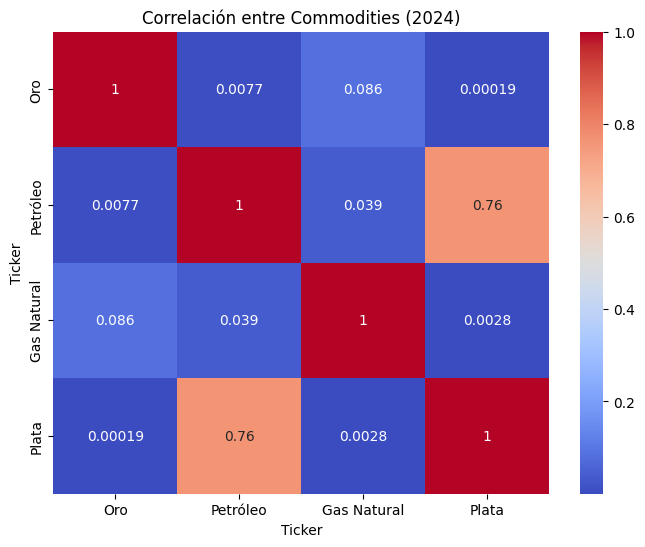

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

data = yf.download(["GC=F", "CL=F", "NG=F", "SI=F"], start="2024-01-01")['Close']
corr = data.pct_change().corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm',
            xticklabels=["Oro", "Petróleo", "Gas Natural", "Plata"],
            yticklabels=["Oro", "Petróleo", "Gas Natural", "Plata"])
plt.title('Correlación entre Commodities (2024)')
plt.show()

/tmp/ipykernel_3022/2151244440.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2024-01-01", end="2025-01-01")['Close']
[*********************100%***********************]  10 of 10 completed


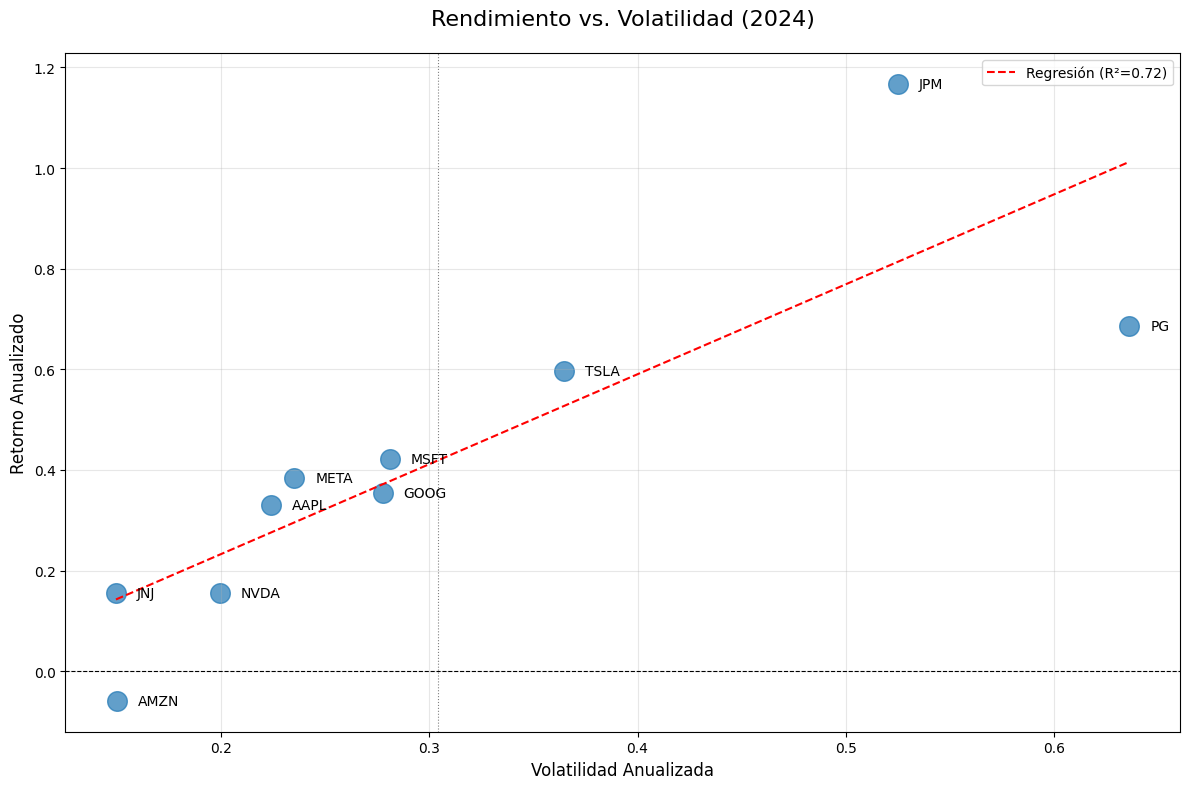

In [ ]:
#Gráfico con recta de regresión
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import stats

# Descargar datos de acciones del S&P 500
tickers = ['AAPL', 'MSFT', 'GOOG', 'AMZN', 'META', 'TSLA', 'NVDA', 'JPM', 'JNJ', 'PG']
data = yf.download(tickers, start="2024-01-01", end="2025-01-01")['Close']

# Calcular rendimiento anualizado y volatilidad
returns = data.pct_change().dropna()
annual_returns = returns.mean() * 252  # 252 días de trading
annual_volatility = returns.std() * np.sqrt(252)

# Crear DataFrame con los resultados
df = pd.DataFrame({
    'Ticker': tickers,
    'Retorno': annual_returns,
    'Volatilidad': annual_volatility
})

# Configurar el gráfico
plt.figure(figsize=(12, 8))
plt.scatter(df['Volatilidad'], df['Retorno'], s=200, alpha=0.7)

# Añadir etiquetas con los tickers
for i, row in df.iterrows():
    plt.text(row['Volatilidad']+0.01, row['Retorno'], row['Ticker'],
             fontsize=10, ha='left', va='center')

# Añadir línea de regresión
slope, intercept, r_value, p_value, std_err = stats.linregress(df['Volatilidad'], df['Retorno'])
x = np.linspace(df['Volatilidad'].min(), df['Volatilidad'].max(), 100)
plt.plot(x, intercept + slope*x, 'r--', label=f'Regresión (R²={r_value**2:.2f})')

# Personalizar el gráfico
plt.title('Rendimiento vs. Volatilidad (2024)', fontsize=16, pad=20)
plt.xlabel('Volatilidad Anualizada', fontsize=12)
plt.ylabel('Retorno Anualizado', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()

# Destacar puntos interesantes
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.axvline(df['Volatilidad'].mean(), color='gray', linestyle=':', linewidth=0.8)

plt.tight_layout()
plt.show()

In [ ]:
#Visualización de retornos acumulados
import yfinance as yf
import pandas as pd

# Descargar datos de activos (acciones y BTC)
tickers = ["AAPL", "MSFT", "BTC-USD", "TSLA", "GLD"]

data = yf.download(tickers, start="2020-01-01", end="2024-12-31")["Close"]
data.head(5)

/tmp/ipykernel_3022/2206909112.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2020-01-01", end="2024-12-31")["Close"]
[*********************100%***********************]  5 of 5 completed


Ticker,AAPL,BTC-USD,GLD,MSFT,TSLA
Date,,,,,
2020-01-01,NaN,7200.174316,NaN,NaN,NaN
2020-01-02,72.333885,6985.470215,143.949997,151.829529,28.684
2020-01-03,71.630653,7344.884277,145.860001,149.938995,29.534
2020-01-04,NaN,7410.656738,NaN,NaN,NaN
2020-01-05,NaN,7411.317383,NaN,NaN,NaN


In [ ]:
# Gráficos

import plotly.express as px

# Retornos acumulados normalizados
returns = data.pct_change().dropna()
cumulative_returns = (1 + returns).cumprod()

fig = px.line(cumulative_returns, title="Retornos Acumulados (2020-2023)")
fig.show()

/tmp/ipykernel_3022/465470077.py:6: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = data.pct_change().dropna()


In [ ]:
!pip install riskfolio-lib --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.9/319.9 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 314.2/314.2 kB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 451.7/451.7 kB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.4/300.4 kB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 111.5 MB/s eta 0:00:00


/tmp/ipykernel_3022/2779856270.py:5: FutureWarning:

The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.



              weights
AAPL     1.468461e-01
BTC-USD  1.826136e-01
GLD      5.073826e-01
MSFT     1.961652e-08
TSLA     1.631576e-01


<Axes: title={'center': 'Cartera Óptima'}>

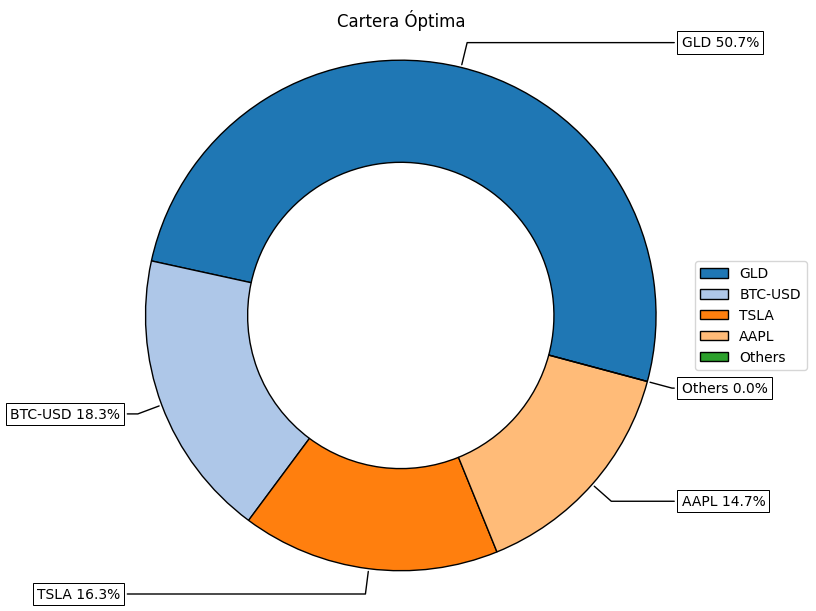

In [ ]:
#Visualización de cartera óptima
import riskfolio as rp

# Calculamos retornos
returns = data.pct_change().dropna()

# Configuramos la cartera
port = rp.Portfolio(returns=returns)
port.assets_stats(method_mu='hist', method_cov='hist')

# Optimizamos (Max Sharpe Ratio)
port.solvers = ['CLARABEL']  # Alternativa si no tienes MOSEK
w = port.optimization(model='Classic', rm='MV', obj='Sharpe', rf=0.0, hist=True)

# Mostramos pesos óptimos
print(w)

# Visualización
rp.plot_pie(w=w, title='Cartera Óptima')

In [ ]:
import plotly.express as px

etfs = {
    "SPY": "EE.UU.",
    "EWU": "Reino Unido",
    "EWG": "Alemania",
    "EWJ": "Japón",
    "EEM": "Mercados Emergentes"
}

data = yf.download(list(etfs.keys()), period="1y")['Close']
weights = data.iloc[-1] / data.iloc[-1].sum()

fig = px.treemap(
    names=[etfs[t] for t in weights.index],
    parents=['Global']*len(weights),
    values=weights*100,
    title='Distribución por Región (Último Cierre)'
)
fig.show()

/tmp/ipykernel_3022/494889943.py:11: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  5 of 5 completed


Análisis de BITCOIN

In [ ]:
#Importamos librerías necesarias
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, classification_report,
                           roc_curve, auc, accuracy_score)

In [ ]:
## 1. Descarga y preparación de datos
def get_bitcoin_data():
    print("Descargando datos de Bitcoin...")
    btc = yf.download("BTC-USD", start="2020-01-01", end="2024-01-01")
    btc = btc[['Close']].copy()

    # Crear variable objetivo
    btc['Return'] = btc['Close'].pct_change()
    btc['Target'] = (btc['Return'].shift(-1) > 0).astype(int)

    # Crear features técnicas
    btc['MA_7'] = btc['Close'].rolling(7).mean()
    btc['MA_21'] = btc['Close'].rolling(21).mean()
    btc['Volatility'] = btc['Return'].rolling(7).std()

    # Cálculo manual de RSI
    delta = btc['Return'].diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    avg_gain = gain.rolling(14).mean()
    avg_loss = loss.rolling(14).mean()
    rs = avg_gain / avg_loss
    btc['RSI'] = 100 - (100 / (1 + rs))

    btc = btc.dropna()
    print(f"Datos preparados. Forma final: {btc.shape}")
    return btc

btc = get_bitcoin_data()
btc

/tmp/ipykernel_3022/2628902749.py:4: FutureWarning:

YF.download() has changed argument auto_adjust default to True



Descargando datos de Bitcoin...


[*********************100%***********************]  1 of 1 completed

Datos preparados. Forma final: (1441, 7)


Price,Close,Return,Target,MA_7,MA_21,Volatility,RSI
Ticker,BTC-USD,,,,,,
Date,,,,,,,
2020-01-21,8745.894531,0.010194,0,8787.489397,8148.824730,0.015680,46.326355
2020-01-22,8680.875977,-0.007434,0,8769.470145,8219.334333,0.015857,50.278483
2020-01-23,8406.515625,-0.031605,1,8724.145787,8287.003162,0.019415,49.348659
2020-01-24,8445.434570,0.004630,0,8655.059570,8339.410319,0.015733,46.771577
2020-01-25,8367.847656,-0.009187,1,8572.922294,8384.990839,0.015183,50.726648
...,...,...,...,...,...,...,...
2023-12-27,43442.855469,0.021694,0,43457.016183,42945.413690,0.016483,48.435424
2023-12-28,42627.855469,-0.018760,0,43279.688058,42913.756138,0.017559,47.434284


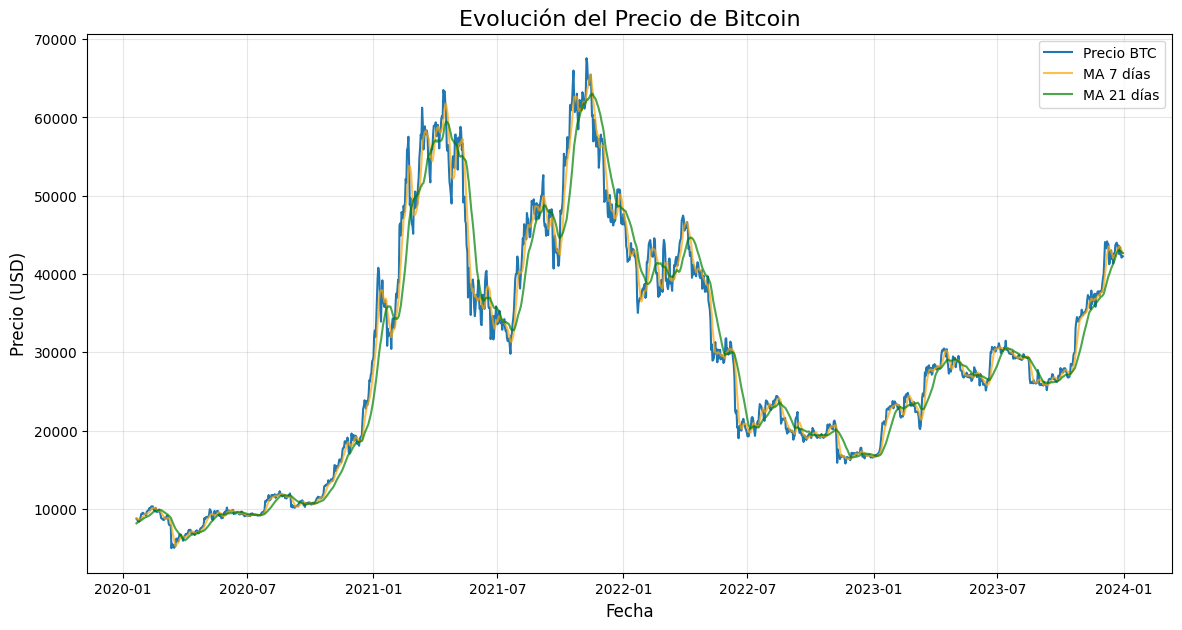

In [ ]:
## 2. Visualización inicial
def plot_initial_data(df):
    plt.figure(figsize=(14, 7))
    plt.plot(df['Close'], label='Precio BTC', color='#1f77b4')
    plt.plot(df['MA_7'], label='MA 7 días', color='orange', alpha=0.7)
    plt.plot(df['MA_21'], label='MA 21 días', color='green', alpha=0.7)
    plt.title('Evolución del Precio de Bitcoin', fontsize=16)
    plt.xlabel('Fecha', fontsize=12)
    plt.ylabel('Precio (USD)', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_initial_data(btc)

In [ ]:
## 3. Preparación de datos para el modelo
features = ['MA_7', 'MA_21', 'Volatility', 'RSI']
X = btc[features].copy()
y = btc['Target'].copy()

# División temporal (más adecuada para datos financieros)
test_size = int(len(X) * 0.3)
X_train, X_test = X.iloc[:-test_size], X.iloc[-test_size:]
y_train, y_test = y.iloc[:-test_size], y.iloc[-test_size:]

print(f"\nDatos divididos: Train {X_train.shape}, Test {X_test.shape}")


Datos divididos: Train (1009, 4), Test (432, 4)


In [ ]:
## 4. Entrenamiento del modelo
print("\nEntrenando modelo...")
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)
print("Modelo entrenado correctamente.")


Entrenando modelo...
Modelo entrenado correctamente.



Evaluando en conjunto de prueba...


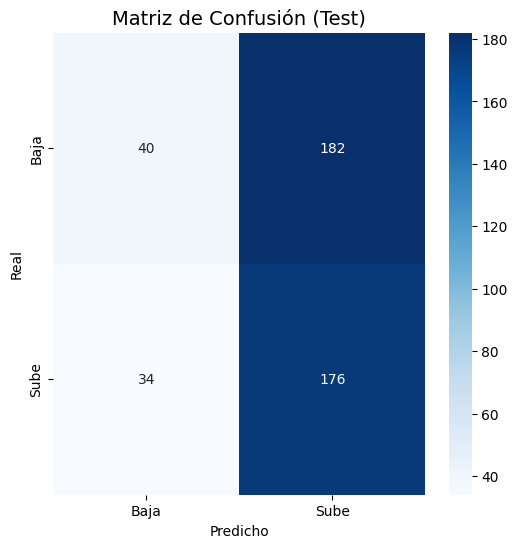


Reporte de Clasificación (Test):
              precision    recall  f1-score   support

           0       0.54      0.18      0.27       222
           1       0.49      0.84      0.62       210

    accuracy                           0.50       432
   macro avg       0.52      0.51      0.44       432
weighted avg       0.52      0.50      0.44       432



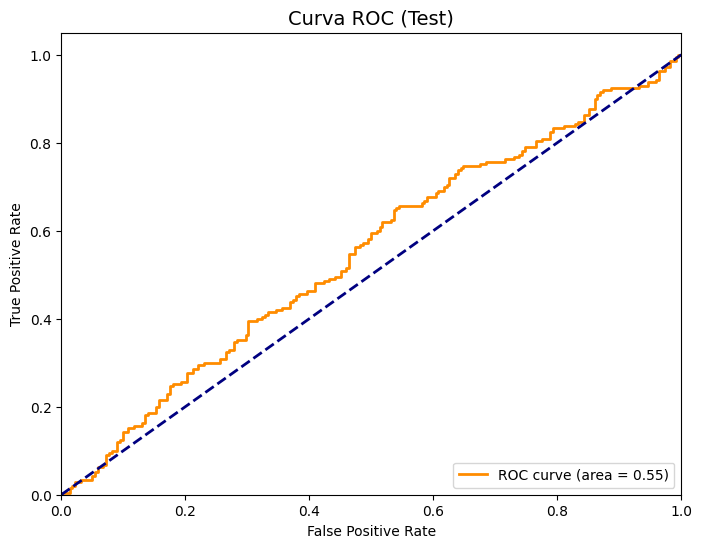

In [ ]:
## 5. Evaluación del modelo
def evaluate_model(model, X, y, dataset_name):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]

    # Matriz de confusión
    cm = confusion_matrix(y, y_pred)
    plt.figure(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Baja', 'Sube'],
                yticklabels=['Baja', 'Sube'])
    plt.title(f'Matriz de Confusión ({dataset_name})', fontsize=14)
    plt.ylabel('Real')
    plt.xlabel('Predicho')
    plt.show()

    # Reporte de clasificación
    print(f"\nReporte de Clasificación ({dataset_name}):")
    print(classification_report(y, y_pred))

    # Curva ROC
    fpr, tpr, thresholds = roc_curve(y, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2,
             label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Curva ROC ({dataset_name})', fontsize=14)
    plt.legend(loc="lower right")
    plt.show()

    return y_pred, y_prob

print("\nEvaluando en conjunto de prueba...")
y_pred, y_prob = evaluate_model(model, X_test, y_test, "Test")

/tmp/ipykernel_3022/91212808.py:10: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




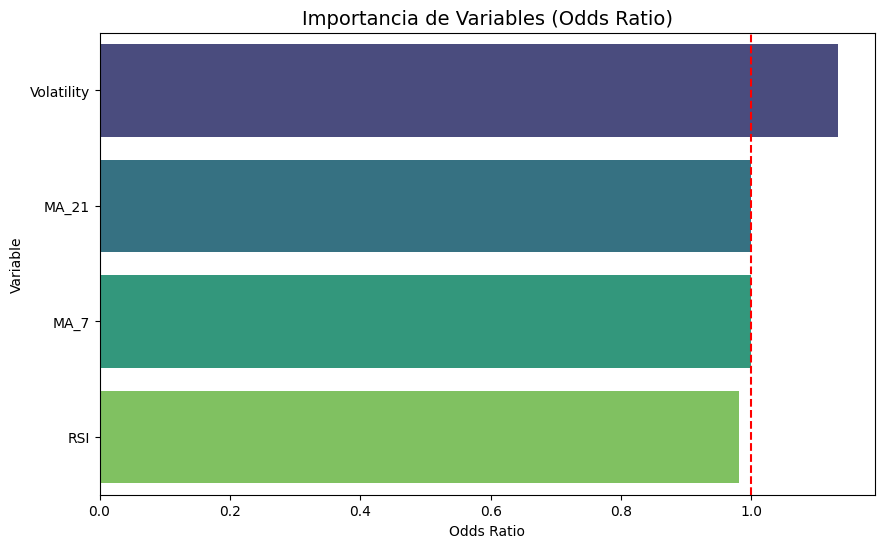


Importancia de Variables:
     Variable  Coeficiente  Odds_Ratio
2  Volatility     0.124215    1.132259
1       MA_21     0.000013    1.000013
0        MA_7    -0.000019    0.999981
3         RSI    -0.018495    0.981675


In [ ]:
## 6. Interpretación del modelo
def plot_feature_importance(model, feature_names):
    importance = pd.DataFrame({
        'Variable': feature_names,
        'Coeficiente': model.coef_[0],
        'Odds_Ratio': np.exp(model.coef_[0])
    }).sort_values('Odds_Ratio', ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Odds_Ratio', y='Variable', data=importance, palette='viridis')
    plt.axvline(x=1, color='red', linestyle='--')
    plt.title('Importancia de Variables (Odds Ratio)', fontsize=14)
    plt.xlabel('Odds Ratio')
    plt.ylabel('Variable')
    plt.show()

    return importance

feature_importance = plot_feature_importance(model, features)
print("\nImportancia de Variables:")
print(feature_importance)


Generando gráfico de predicciones...


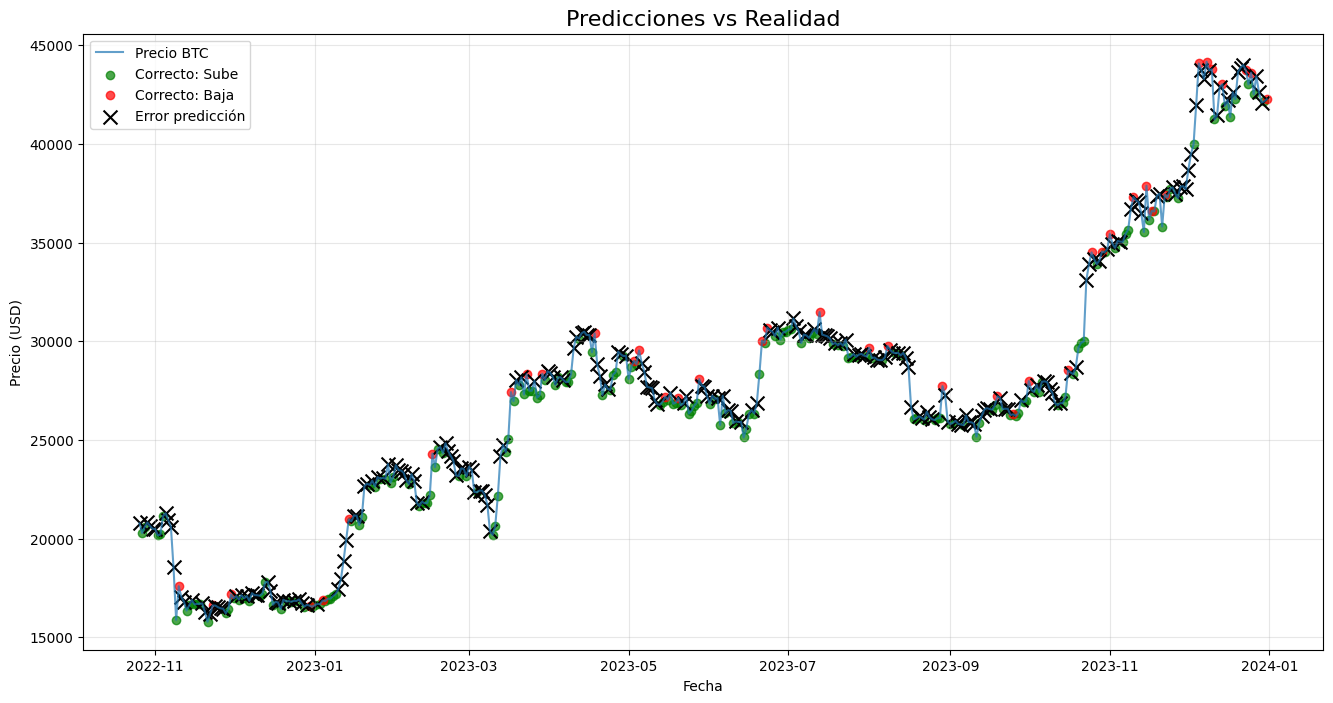

In [ ]:
## 7. Visualización de predicciones
def plot_predictions_with_prices(X_test, y_test, y_pred, y_prob, original_df):
    # Creamos un DataFrame con los resultados
    results = pd.DataFrame({
        'Real': y_test.values,
        'Predicho': y_pred,
        'Probabilidad': y_prob
    }, index=X_test.index)

    # Añadimos precios y retornos
    results['Close'] = original_df.loc[X_test.index, 'Close']
    results['Return'] = original_df.loc[X_test.index, 'Return']

    # Gráfico
    plt.figure(figsize=(16, 8))
    plt.plot(results['Close'], label='Precio BTC', alpha=0.7, color='#1f77b4')

    # Marcadores para predicciones
    correct_up = results[(results['Real'] == 1) & (results['Predicho'] == 1)]
    correct_down = results[(results['Real'] == 0) & (results['Predicho'] == 0)]
    incorrect = results[results['Real'] != results['Predicho']]

    plt.scatter(correct_up.index, correct_up['Close'],
                color='green', label='Correcto: Sube', alpha=0.7)
    plt.scatter(correct_down.index, correct_down['Close'],
                color='red', label='Correcto: Baja', alpha=0.7)
    plt.scatter(incorrect.index, incorrect['Close'],
                color='black', marker='x', s=100, label='Error predicción')

    plt.title('Predicciones vs Realidad', fontsize=16)
    plt.xlabel('Fecha')
    plt.ylabel('Precio (USD)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return results

print("\nGenerando gráfico de predicciones...")
results = plot_predictions_with_prices(X_test, y_test, y_pred, y_prob, btc)

/tmp/ipykernel_3022/4223813866.py:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




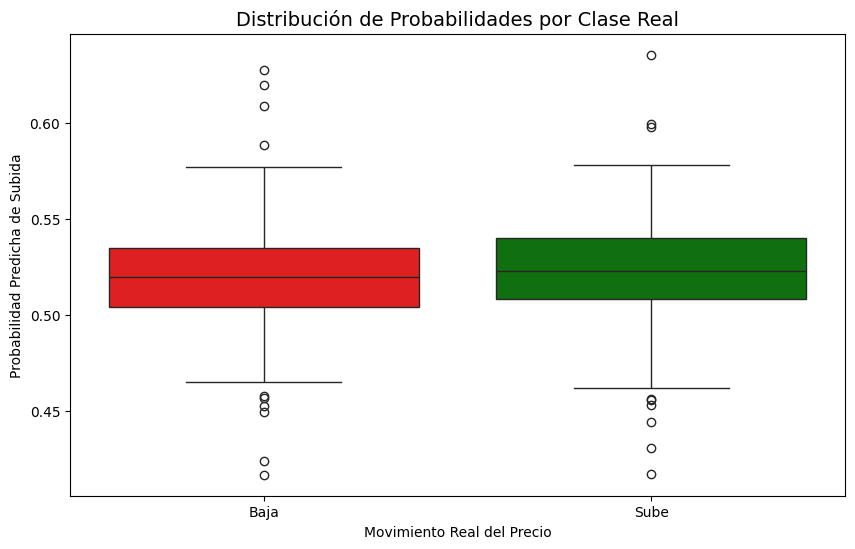


Rendimiento del Modelo:
Precisión: 50.00%
Ganancia acumulada: 61.79%
Ratio de aciertos: 50.00%


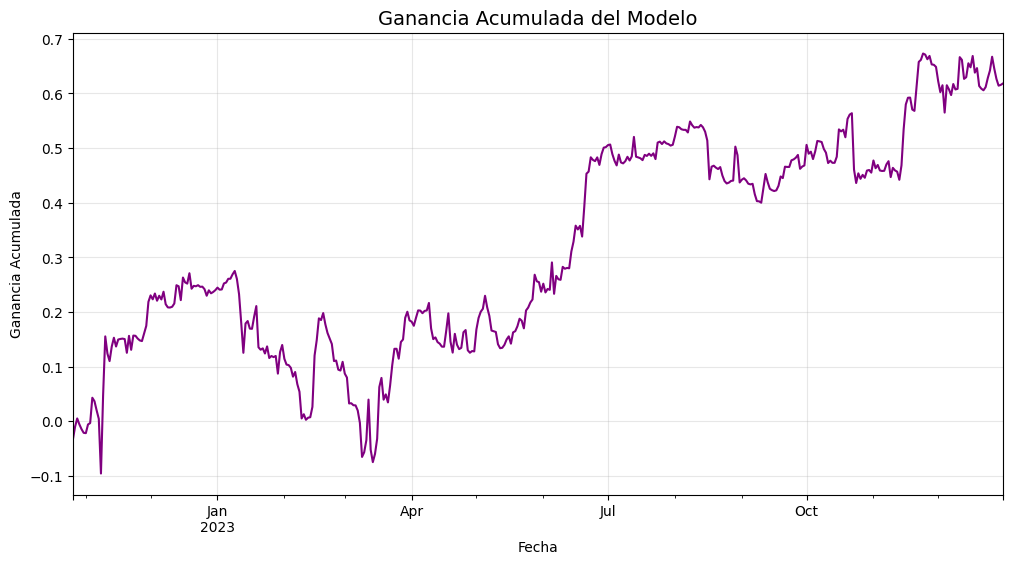


¡Análisis completado exitosamente!


In [ ]:
## 8. Análisis de rendimiento
def analyze_performance(results):
    # Convertir valores a enteros para el palette
    results['Real'] = results['Real'].astype(int)

    # Distribución de probabilidades
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Real', y='Probabilidad', data=results,
                palette=['red', 'green'])  # Usamos lista de colores directamente
    plt.title('Distribución de Probabilidades por Clase Real', fontsize=14)
    plt.xticks([0, 1], ['Baja', 'Sube'])
    plt.xlabel('Movimiento Real del Precio')
    plt.ylabel('Probabilidad Predicha de Subida')
    plt.show()

    # Métricas de trading
    results['Decision'] = np.where(results['Probabilidad'] > 0.5, 1, 0)
    results['Ganancia'] = np.where(
        results['Decision'] == results['Real'],
        abs(results['Return']),
        -abs(results['Return'])
    )

    print("\nRendimiento del Modelo:")
    print(f"Precisión: {accuracy_score(results['Real'], results['Predicho']):.2%}")
    print(f"Ganancia acumulada: {results['Ganancia'].sum():.2%}")
    print(f"Ratio de aciertos: {len(results[results['Ganancia'] > 0])/len(results):.2%}")

    # Gráfico de ganancia acumulada
    results['Ganancia_Acumulada'] = results['Ganancia'].cumsum()

    plt.figure(figsize=(12, 6))
    results['Ganancia_Acumulada'].plot(color='purple')
    plt.title('Ganancia Acumulada del Modelo', fontsize=14)
    plt.xlabel('Fecha')
    plt.ylabel('Ganancia Acumulada')
    plt.grid(True, alpha=0.3)
    plt.show()

analyze_performance(results)
print("\n¡Análisis completado exitosamente!")

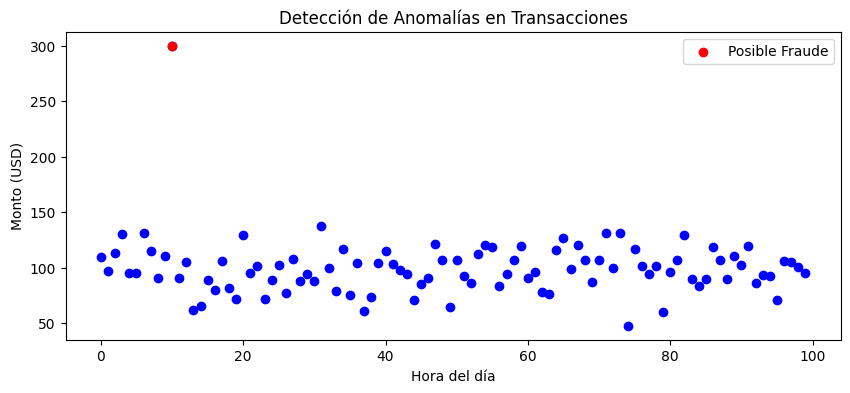

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# Simular datos de transacciones ( montos y horas)
np.random.seed(42)
transactions = pd.DataFrame({
    'Hora': np.arange(100),
    'Monto': np.random.normal(100, 20, 100)
})

# Introducir anomalías
transactions.loc[10, 'Monto'] = 300  # Outlier

# Graficar
plt.figure(figsize=(10, 4))
plt.scatter(transactions['Hora'], transactions['Monto'], color='blue')
plt.scatter(10, 300, color='red', label='Posible Fraude')
plt.title('Detección de Anomalías en Transacciones')
plt.xlabel('Hora del día')
plt.ylabel('Monto (USD)')
plt.legend()
plt.show()

/tmp/ipykernel_3022/1179972946.py:4: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed


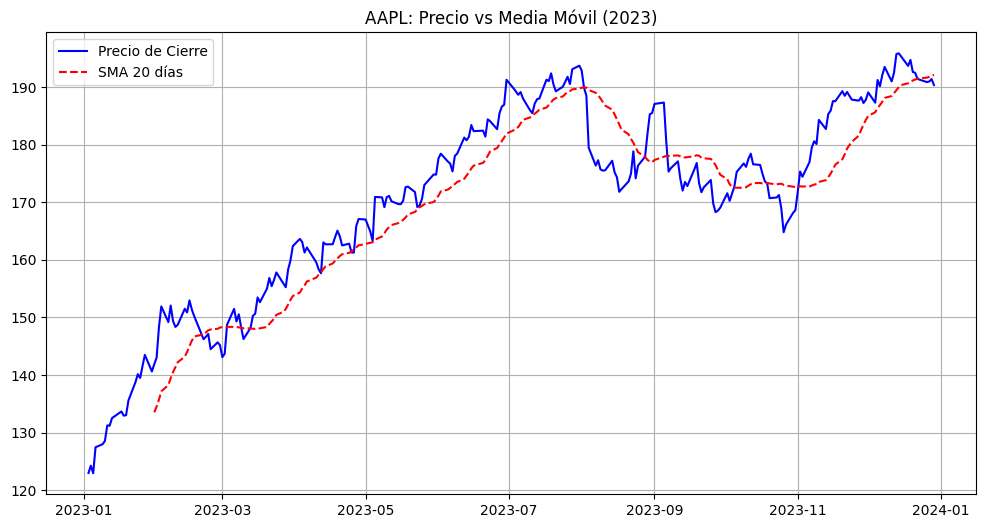

In [ ]:
import matplotlib.pyplot as plt
import yfinance as yf
# Descargar datos de una acción (ej: Apple)
data = yf.download("AAPL", start="2023-01-01", end="2024-01-01")

# Calcular media móvil de 20 días
data['SMA_20'] = data['Close'].rolling(window=20).mean()

# Graficar
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['Close'], label='Precio de Cierre', color='blue')
plt.plot(data.index, data['SMA_20'], label='SMA 20 días', color='red', linestyle='--')
plt.title('AAPL: Precio vs Media Móvil (2023)')
plt.legend()
plt.grid()
plt.show()

/tmp/ipykernel_3022/1551323822.py:6: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning:

No supported index is available. Prediction results will be 

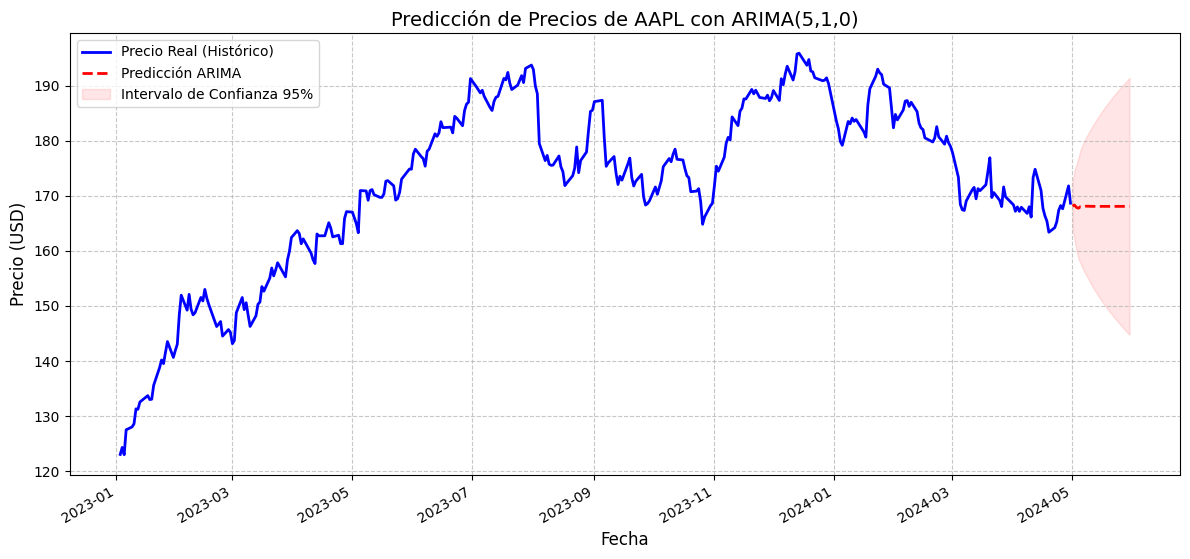

In [ ]:
import matplotlib.pyplot as plt
import yfinance as yf
from statsmodels.tsa.arima.model import ARIMA

# 1. Descargar datos de ejemplo (Apple)
data = yf.download("AAPL", start="2023-01-01", end="2024-05-01")
prices = data['Close']

# 2. Entrenar modelo ARIMA
model = ARIMA(prices, order=(5,1,0))
model_fit = model.fit()

# 3. Predecir 30 días futuros
forecast = model_fit.get_forecast(steps=30)
pred_mean = forecast.predicted_mean  # Valores predichos
conf_int = forecast.conf_int()  # Intervalos de confianza

# 4. Crear gráfico
plt.figure(figsize=(12, 6))

# Gráfico histórico (azul)
plt.plot(prices.index, prices, label='Precio Real (Histórico)',
         color='blue', linewidth=2)

# Gráfico de predicción (rojo)
pred_dates = pd.date_range(start=prices.index[-1], periods=31)[1:]
plt.plot(pred_dates, pred_mean, label='Predicción ARIMA',
         color='red', linestyle='--', linewidth=2)

# Rellenar área de confianza (sombra roja)
plt.fill_between(pred_dates,
                 conf_int.iloc[:,0],
                 conf_int.iloc[:,1],
                 color='red', alpha=0.1, label='Intervalo de Confianza 95%')

# Personalización del gráfico
plt.title('Predicción de Precios de AAPL con ARIMA(5,1,0)', fontsize=14)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Precio (USD)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=10)
plt.tight_layout()

# Mostrar fechas en formato legible
plt.gcf().autofmt_xdate()

plt.show()